# AP 155 Lab Exercise
---
## Exercise 3: Numbers in Computers II

_Instructions_: 
- **Output 1: Horner's Rule**. Create a solver of polynomial equations by direct evaluation and by Horner's rule. Create a figure comparing execution times, and deviations in result.
- **Output 2: Horner's Rule for Taylor Series**. Apply Horner's rule to create special functions without importing libraries. Create figures plotting these functions.

### Student Information
- _Full Name (Last Name, First Name)_: Pasion, Kyla Zarina
- _Student No._: 2024-09224
- _Section_: WX-1

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1G9tPPcyMUag91g_R02O0wsGYPiZWy5Nn/view?usp=drive_link) (Note: percentages may still be tweaked)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 | 
| Code appropriateness  | XX | 20 | 
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Report

### Problem 1: Horner's Rule (Gezerlis Problem 2.11)


![Execution Time vs. Polynomial Size Plot of Problem 1](./Figures/e3_figure1_1.png)


**Figure 1.** The execution time of the naive and Horner's rule methods as the polynomial size increases from $n=1$ to $500$. Horner's rule remains consistently faster and more stable in runtime, while the naive method generally takes longer and shows several latency spikes due to the repeated calculation of powers.

![Absolute Deviation vs. Polynomial Size Plot of Problem 1](./Figures/e3_figure1_2.png)

**Figure 2.** The absolute deviation between the results of the naive and Horner's rule methods as the polynomial size increases. The deviation is negligible for smaller polynomials but grows rapidly at larger $n$, reaching approximately $1.0\times10^{146}$ near $n=500$, showing the increasing numerical difference between the two evaluation methods.


### Problem 2: Taylor Series Evaluation

![The Taylor series approximation of $e^x$](./Figures/e3_figure2.png)

**Figure 3.** The Taylor series approximation of $e^x$ evaluated using Horner's rule compared with `np.exp()` over $x \in [0,10]$. The two curves overlap almost perfectly, showing that the Taylor approximation provides highly accurate values across the given range while Horner's rule evaluates the polynomial efficiently.

![The Taylor series approximation of $\sin(x)$](./Figures/e3_figure3.png)

**Figure 4.** The Taylor series approximation of $\sin(x)$ evaluated using Horner's rule compared with `np.sin()` over $x \in [0,10]$. The approximation closely overlaps with the NumPy result throughout the interval, demonstrating that the Taylor series with the chosen number of terms accurately represents $\sin(x)$ over the tested range.

### Other comments
- I like this exercise


---
## Section 2: Code

### Problem 1: Horner's Rule (Gezerlis Problem 2.11)

This problem discusses error buildup when trying to evaluate polynomials without and with the use of *Horner's rule*. Take a polynomial of degree $n - 1$:

$$P(x) = p_0 + p_1 x + p_2 x^2 + p_3 x^3 + \dots + p_{n-1} x^{n-1} \tag{2.98}$$

Write a function that takes in a list containing the $p_i$'s, say `coeffs`, and the point $x$ and evaluates the value of $P(x)$ in the naive way, i.e., from left to right like how you would normally do it. You are not allowed to import any library such as `numpy`.


In [1]:
# Define a function that evaluates the polynomial using the naive method
def naive_polynomial(coeffs,x):

    # Start the polynomial value at zero
    result = 0.0

    # Loop through the coefficients and their corresponding powers
    # The first coefficient has power 0, the second has power 1 and so on 
    for i, coeff in enumerate(coeffs):

        # Solve each term explicitly from left to right and add it to the running polynomial value
        result += coeff * x**i

    return result


Notice that this way of coding up the polynomial contains several (needless) multiplications. This is so because $x^i$ is evaluated as $x \times x \times \dots \times x$ (where there are $i - 1$ multiplications). Thus, this way of approaching the problem corresponds to:

$$1 + 2 + \dots + n - 2 = \frac{(n - 1)(n - 2)}{2} \tag{2.99}$$

multiplications, from $x^2$ all the way up to $x^{n-1}$. If we rewrite the polynomial:

$$P(x) = p_0 + x(p_1 + x(p_2 + x(p_3 + \dots + x(p_{n-2} + xp_{n-1})\dots))) \tag{2.100}$$

then we can get away with only $n - 1$ multiplications (i.e., no powers are evaluated). This is obviously more efficient, but equally important is the fact that this way we can substantially limit the accumulation of rounding error (especially for polynomials of large degree). 

Write a function that takes in a list containing the $p_i$'s, say `coeffs`, and the point $x$ and evaluates the value of $P(x)$ in the new way, i.e., from right to left. You are not allowed to import any library such as `numpy`. Apply the previous two functions to the (admittedly artificial) case of:

`coeffs = [(-11)**i for i in reversed(range(8))]`  
and `x = 11.01`. Observe any discrepancy and discuss its origin.

In [2]:
# Coefficient list
# The reversed(range(8)) helps solve the problem from right to left
coeffs = [(-11)**i for i in reversed(range(8))]

# Set the value of x 
x = 11.01

# Define a function tha evaluates the polynomial using Horner's rule
def horner_polynomial(coeffs, x):

    # Start with the coefficient of the highest power of x
    result = coeffs[-1]

    # Process the remaining coefficients from right to left
    for coeff in reversed(coeffs[:-1]):

        # Multiply the current result by x and add the next coefficient
        # This avoids explicitly calculating powers in the polynomial
        result = coeff + x * result

    return result

# Evaluate the polynomial using the naive method
naive_result = naive_polynomial(coeffs, x)

# Evaluate the polynomial using the Horner's rule
horner_result = horner_polynomial(coeffs, x)

# Calculate the absolute difference between the two results
difference = abs(naive_result - horner_result)

print("Coefficients:", coeffs)
print("x =", x)
print("Naive method:", naive_result)
print("Horner's rule method:", horner_result)
print("Absolute difference:", difference)


Coefficients: [-19487171, 1771561, -161051, 14641, -1331, 121, -11, 1]
x = 11.01
Naive method: 71056.02362162992
Horner's rule method: 71056.02362163365
Absolute difference: 3.725290298461914e-09


Extend your work by testing both functions over increasing polynomial degrees $n \in [1, 500]$ evaluated at $x=2$. Measure execution times with the `time` library and track the absolute deviation $|P_{\text{naive}}(x) - P_{\text{Horner}}(x)|$. Plot the results side by side with `matplotlib` or `seaborn`.

Maximum deviation: 9.989595361011175e+145


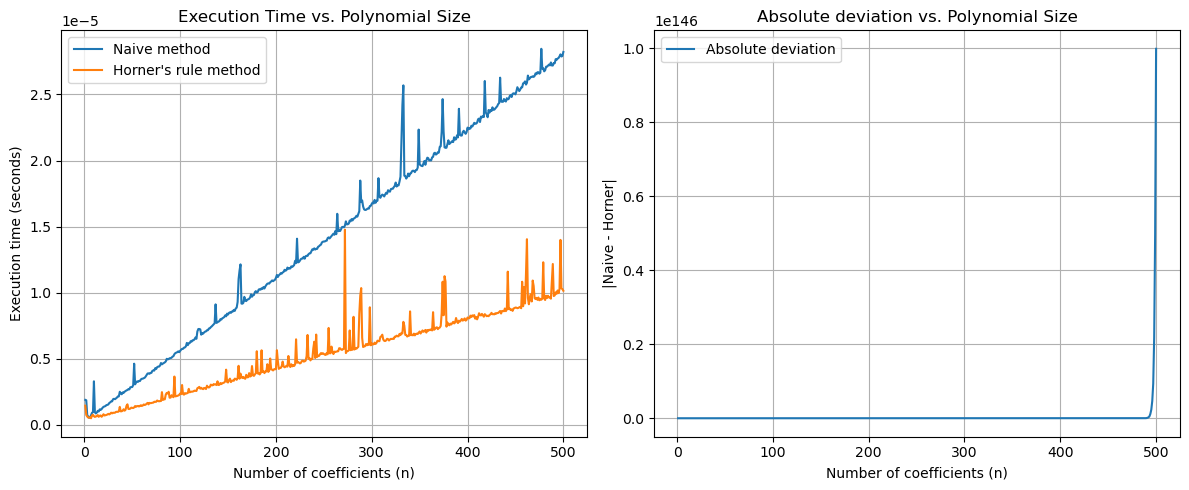

In [3]:
import matplotlib.pyplot as plt
import time

# Create a list containing polynomial sizes from 1 to 500
n_values = list(range(1,501))

# Create empty lists to store the execution times and absolute deviation
naive_times = []
horner_times = []
deviations = []

x = 2.1

# Loop through every polynomial size from 1 to 500
for n in n_values:
    coeffs = [1.0] * n # Set the coefficient to 1  


    # --- Measure the naive method ---
    
    # Record the starting time before evaluating the polynomial
    start = time.perf_counter()

    naive_result = naive_polynomial(coeffs, x)

    # Record the ending time after the calculation
    end = time.perf_counter()

    # Calculate the total execution time
    naive_time = end - start

    # Store the execution time in the list
    naive_times.append(naive_time)

    # --- Measure the Horner's rule method ---
    
    # Record the starting time before evaluating the polynomial
    start = time.perf_counter()

    horner_result = horner_polynomial(coeffs, x)

    # Record the ending time after the calculation
    end = time.perf_counter()

    # Calculate the total execution time
    horner_time = end - start

    # Store the execution time in the list
    horner_times.append(horner_time)

    # --- Calculate the absolute deviation ---
    deviation = abs(naive_result - horner_result)
    deviations.append(deviation) # Store the deviation

# Plot the results
    
# --- Plot 1: Execution time ---
fig, axes = plt.subplots(1, 2, figsize=(12,5))

axes[0].plot(n_values, naive_times, label="Naive method")
axes[0].plot(n_values, horner_times, label="Horner's rule method")
axes[0].set_title("Execution Time vs. Polynomial Size")
axes[0].set_xlabel("Number of coefficients (n)")
axes[0].set_ylabel("Execution time (seconds)")
axes[0].legend()
axes[0].grid(True)

# --- Plot 2: Absolute deviation ---
axes[1].plot(n_values, deviations, label="Absolute deviation")
axes[1].set_title("Absolute deviation vs. Polynomial Size")
axes[1].set_xlabel("Number of coefficients (n)")
axes[1].set_ylabel("|Naive - Horner|")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show

print("Maximum deviation:", max(deviations))

#### Problem 1 code summary

This code evaluates a polynomial using both the naive method and Horner's rule, where the naive method calculates each power explicitly while Horner's rule rewrites the polynomial to reduce repeated power operations. Their execution times and numerical differences are compared for increasing polynomial sizes to examine the computational efficiency and numerical behavior of the two approaches.

---

### Problem 2: Taylor Series Evaluation

By applying Horner's rule without using any libraries, create a function to evaluate $f(x) = e^x$ based on its Taylor series approximation. Plot for $x \in [0,10]$. Compare with `np.exp()`.

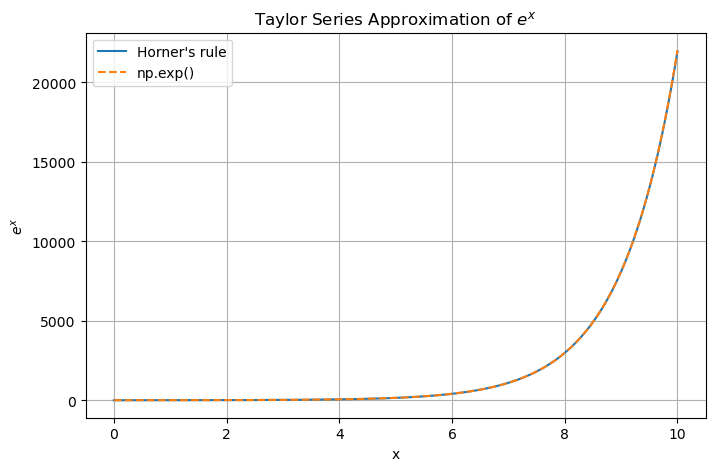

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Evaluate e^x using the Taylor series and Horner's rule
def horner_exp(x, n_terms=20):
    result = 1.0

    # Start from the highest Taylor-series term
    for k in range(n_terms - 1, 0, -1):
        result = 1 + (x / k) * result

    return result


# Generate x-values from 0 to 10
x_values = np.linspace(0, 10, 500)

# Evaluate using Horner's rule
horner_values = [horner_exp(x, 20) for x in x_values]

# Evaluate using NumPy
numpy_values = np.exp(x_values)


# Plot the results
plt.figure(figsize=(8, 5))

plt.plot(x_values, horner_values, label="Horner's rule")
plt.plot(x_values, numpy_values, "--", label="np.exp()")

plt.xlabel("x")
plt.ylabel("$e^x$")
plt.title("Taylor Series Approximation of $e^x$")
plt.legend()
plt.grid(True)

plt.show()

Again, by applying Horner's rule without using any libraries, create function to evaluate $f(x) = \sin(x)$ using its Taylor series approximation. Can you avoid evaluating exponents completely? If not, how can you minimize these operations? Plot the result for $x \in [0,10]$. Compare with `np.sin()`.

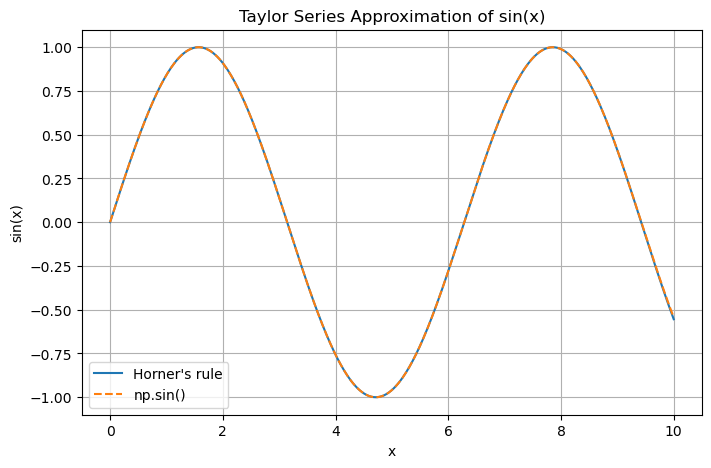

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Evaluate sin(x) using its Taylor series and Horner's rule
def horner_sin(x, n_terms=15):

    x2 = x * x
    result = 0.0

    # Evaluate the polynomial from the highest-order term
    for k in range(n_terms - 1, 0, -1):
        result = 1 - (x2 / ((2*k) * (2*k + 1))) * result

    return x * result


# Generate x-values from 0 to 10
x_values = np.linspace(0, 10, 500)

# Evaluate using Horner's rule
horner_values = [horner_sin(x, 15) for x in x_values]

# Evaluate using NumPy
numpy_values = np.sin(x_values)


# Plot the results
plt.figure(figsize=(8, 5))

plt.plot(x_values, horner_values, label="Horner's rule")
plt.plot(x_values, numpy_values, "--", label="np.sin()")

plt.xlabel("x")
plt.ylabel("sin(x)")
plt.title("Taylor Series Approximation of sin(x)")
plt.legend()
plt.grid(True)

plt.show()

#### Problem 2 code summary

These code approximate $e^x$ and $\sin(x)$ using their Taylor series expansions and evaluate the resulting polynomials with Horner's rule. The Taylor series provides polynomial approximations to the functions, while Horner's rule is used to evaluate them more efficiently by reducing repeated power calculations. The results are compared with `np.exp()` and `np.sin()` over $x \in [0,10]$ to examine the accuracy of the approximations.

---
## Section 3: Tutorials

### Floating-point representation

Python uses 64-bit float by default for any number you type in with a decimal point. Different floating point precision can be used at a lower level, which we can go around by using [Numpy dtypes](https://numpy.org/doc/stable/reference/arrays.dtypes.html). 

Useful links:
* [(Goldberg, 1991) *What every computer scientist should know about floating-point arithmetic*](https://dl.acm.org/doi/10.1145/103162.103163)
* [Wikipedia - Floating-point arithmetic](https://en.wikipedia.org/wiki/Floating-point_arithmetic)
* [Data types - NumPy](https://numpy.org/doc/stable/user/basics.types.html)
* [decimal — Decimal fixed-point and floating-point arithmetic](https://docs.python.org/3/library/decimal.html)
* [fractions — Rational numbers](https://docs.python.org/3/library/fractions.html)

In [6]:
import matplotlib.pyplot as plt
import numpy as np

from decimal import Decimal
from fractions import Fraction

# Classic floating point quirks example
print(0.1 + 0.2)

# How about increasing precision?
print(np.float128(0.1) + np.float128(0.2))

# How bad is decreasing precision?
print(np.float16(0.1) + np.float16(0.2))

# Closest we could get to fixed-point arithmetic: decimal
print(Decimal(0.1) + Decimal(0.2))

# How about using an explicit Fraction object type?
print(float(Fraction(1, 10) + Fraction(1, 5)))

0.30000000000000004
0.30000000000000001665
0.2998
0.3000000000000000166533453694
0.3


### Basics

In [7]:
x = 0.5 # floats
y = 1 # integer
z = 'Hello' # string

x, y = y, x # swapping variables
a, b = 2, 3 # multiple assignments
print(x)
print(y)

1
0.5


In [8]:
x + y # sum
x - y # difference
x * y # multiplication
x / y # division
x // y # floor division
x % y # modulo
x ** y # power

1.0

### Control flow

In [9]:
x = 0

if x!= 0:
    print("x is nonzero")
elif x==0:
    print("x is zero")

x is zero


In [10]:
y = 25
if (y%5==0) == True:
    print('y is divisible by 5')

y is divisible by 5


In [11]:
# you can write truthiness conditionals more succinctly as 
# if condition is True, mathematically a True equals 1.0 while a False equals 0.0
if not (y%5):
    print('y is divisible by 5')

y is divisible by 5


In [12]:
for i in range(1,15,2):
    print(0.01*i, end=" ") # the end=" " syntax tells the value shall be printed in line

0.01 0.03 0.05 0.07 0.09 0.11 0.13 

### Data structures

In [13]:
xs = []
for i in range(20):
    xs.append(0.1*i)

# BE CAREFUL!!!
# list is different from array
list1 = [1, 2, 3]
list2 = [4, 5, 6]
list1 + list2 # concatenates

[1, 2, 3, 4, 5, 6]

In [14]:
list1 = np.array([1, 2, 3])
list2 = np.array([4, 5, 6])
list1 + list2 # adds element-wise!

array([5, 7, 9])

In [15]:
# Tuples are primarily used to bundle related pieces of data together, 
# protect data from accidental modification, and optimize performance.

tuple1 = (1, 2, 3)
tuple1[1]  # can be indexed just like lists

2

In [16]:
# strings can also be indexed like numbers

name = "Wilson"
name[0]

'W'

In [17]:
# string dot format arguments

x, y = 3.1, - 2.5
"{0:1.15f} {1:1.0f}".format(x, y) 

# the general string format looks like "{2} {0} {1}".format(a, b, c)
# the number inside the curly brackets contain the index of the variables inside the format( ... )
# you can modify the numbers outputted by specifiying the datatype inside the curly bracket 
# {0:1.15f} means print the zeroth number and print the number as a float with 15 decimal places 
# {1: 1.0f} means print the 1st number (second actually) and print as a float with 0 decimal places

'3.100000000000000 -2'

In [18]:
# slicing a list creates a new list

xs = [1, 2, 3]
ys = xs[1:] # the square bracket after a list corresponds to index (start:end) ... (start:end:interval)
zs = xs[:] # [:] means copy everything --> create an exact (shallow) copy of xs
print(xs)
print(ys)

# shallow copy duplicates an object's top-level properties 
# but keeps references to any nested objects, meaning changes to nested data affect the original. 
# A deep copy fully clones all levels and nested structures,
# creating a completely independent duplicate where changes do not affect the original.

[1, 2, 3]
[2, 3]


In [19]:
import copy
from copy import deepcopy

original = [1, 2, [3, 4]] # notice the list inside a list
shallow_copied = original[:]

# modifying a top-level element
shallow_copied[0] = 99
print("After modifying top-level element:")
print(f"Original: {original}")        
print(f"Copied:   {shallow_copied}")  

# modifying a nested mutable element
shallow_copied[2][0] = "changed" 
print("\nAfter modifying nested element (SHALLOW):") # BTW \n in string means paragraph break
print(f"Original: {original}")        
print(f"Copied:   {shallow_copied}")  

deep_copied = deepcopy(original)
original = [1, 2, [3, 4]]
deep_copied[2][0] = "changed" 
print("\nAfter modifying nested element (DEEP COPIED):") # BTW \n in string means paragraph break
print(f"Original: {original}")        
print(f"Copied:   {deep_copied}")  

After modifying top-level element:
Original: [1, 2, [3, 4]]
Copied:   [99, 2, [3, 4]]

After modifying nested element (SHALLOW):
Original: [1, 2, ['changed', 4]]
Copied:   [99, 2, ['changed', 4]]

After modifying nested element (DEEP COPIED):
Original: [1, 2, [3, 4]]
Copied:   [1, 2, ['changed', 4]]


In [20]:
# dictionaries

htow = {1.41: 31.3, 1.45: 36.7, 1.48: 42.4} # is a dictionary associating heights to weights
# each entry is separated by a comma,
# each entry is composed of keys and items
# the first key is 1.41 with corresponding 31.3 item

for key, item in htow.items():
    print(f'key is {key} with item {item}')

# dictionaries are pretty useful for collecting a parallel set of content
# you can use strings as keys too

key is 1.41 with item 31.3
key is 1.45 with item 36.7
key is 1.48 with item 42.4


### User-defined functions

In [21]:
# start with def<space>name_of_your_function(input, parameters):
# end with return
# once a function encounters return, it ends all operations and sends the value back to the caller

def sumofints(nmax):
    val = sum(range(1,nmax+1))
    return val

# use the above function as
x = sumofints(42)
print(x)

# you could have multiple inputs and outputs
# functions can also return multiple values (effectively the output is a tuple for such cases)

903


In [22]:
from math import cos

def cosder(x, h=0.01): # here h is a default parameter (meaning it already has a preset value)
    return (cos(x+h) - cos(x))/h

#You can call this function with either 
cosder(0.)
#or 
cosder(0., 0.001)
#ie the 2nd argument is optional

-0.0004999999583255033

In [23]:
# you can also pass functions as inputs
def der(f, x, h=0.01):
    return (f(x+h) - f(x))/h

### List comprehensions

"Using such alternative syntax to make the code more concise and ex-
pressive helps us write new programs, but also makes the lives of future readers easier. Of
course, you do have to exercise your judgement."

In [24]:
def f(x):
    return x//2

xs = [0.1*i for i in range(20)] 
ys = [2*x for x in xs] # multiplication operation with a list
ws = [f(x) for x in xs] # evaluating a function with elements of a list
zs = [2*x for x in xs if x>0.3] # pruning a list

### Basic plotting

- We will utilize NumPy and Matplotlib for most of our visualization
    - `import numpy as np` # Docs: https://numpy.org/doc/stable/reference/
    - `import matplotlib.pyplot as plt` # Docs: https://matplotlib.org/stable/api/pyplot_summary.html
  
- We will use Seaborn only to make the defaults look pretty.
- Our focus is to make plotting as flexible as possible.
- Check out its documentation if you're interested with its convenience features.
    - `import seaborn as sns` # Guide: https://seaborn.pydata.org/tutorial/introduction.html
    `sns.set_theme(style="darkgrid")`

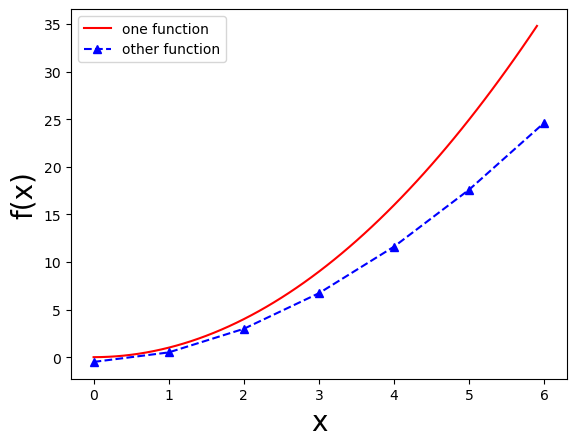

In [25]:
import matplotlib.pyplot as plt

def plotex(cxs,cys,dxs,dys):
    plt.xlabel('x', fontsize=20)
    plt.ylabel('f(x)', fontsize=20)
    plt.plot(cxs, cys, 'r-', label='one function')
    plt.plot(dxs, dys, 'b--^', label='other function')
    plt.legend()
    plt.show()

cxs = [0.1*i for i in range(60)]
cys = [x**2 for x in cxs]
dxs = [i for i in range(7)]
dys = [x**1.8 - 0.5 for x in dxs]

plotex(cxs, cys, dxs, dys)

<ErrorbarContainer object of 3 artists>

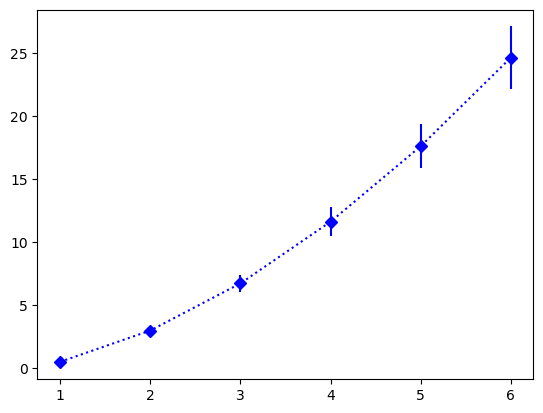

In [26]:
dyerrs = [0.1*y for y in dys]
plt.errorbar(dxs[1:], dys[1:], dyerrs[1:], fmt='b:D', label='with errors')

### NumPy idioms

<img src="figures/gezerlisTable1_2.png" width="67%">

In [27]:
import numpy as np

# for parallel computations: contribs = [w*f(x) for w,x in zip(ws,xs)]

zs = np.array([5, 8], dtype=np.float32) # converts contribs into a NumPy array
A, B, C = np.zeros(5), np.ones(4), np.arange(6)

print(A)
print(B)
print(C)

[0. 0. 0. 0. 0.]
[1. 1. 1. 1.]
[0 1 2 3 4 5]


In [28]:
# you can specify set of points

np.linspace(1, 10, 6) # 6 linearly spaced points from 1 to 10 (including 1 and 10)
np.arange(1, 10, 6) # from 1 to 10 in steps of 6
np.logspace(1, 10, 6) # 6 logarithmically spaced points from 1 to 10

# if you're not sure what to input, you can always shift+Tab inside the parenthesis to check the arguments

array([1.00000000e+01, 6.30957344e+02, 3.98107171e+04, 2.51188643e+06,
       1.58489319e+08, 1.00000000e+10])